Plan for tmr: use processor from lucas' code, for filtered and unfiltered. plot unfiltered as a grid and overlay the other one on top. and inspect the unfiltered to see if spatially bowed. - thats for lon lat

for height use centreline and do dist from centreline, could plot height vs heights in the same local bit. - configurable for how big the local size is. H=h+deltah.take H for local and -mean H of 20 points, pick a point and make the radii configurable and find the points inside.

In [57]:
#imports!
import xarray as xr  # in case use .nc later
import zipfile
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import os
!pip install rarfile
import rarfile
!pip install rarfile h5netcdf
from shapely.geometry import LineString, MultiLineString
import numpy as np

In [41]:
#config!
angle_tol = 20   # angle change from perp
min_run = 3      # min runs for perp points
search_radius = 500     #500m from the centreline
slice_half_length = 30  # metres along the river, for the cross-river slice
slice_half_width = 250  # metres across the river, for the cross-river slice

zip_path = "/content/Orco_river.zip"
extract_folder = "/content/Orco"
centreline_file = "/content/Orco/Orco_CL_25832.kml"
pixc_file = "/content/Orco/Orco_processed/PIXC_029_234R_20250408.geojson"  # this date file has the best temporal alignment
aoi_file = "/content/Orco_shapefile_uav.shp"
nc_file = "/content/SWOT_L2_HR_PIXC_031_029_234R_20250408T044534_20250408T044545_PGD0_01.nc"


ground_track_rar = "/content/sat_paths.rar"
ground_track_folder = "/content/sat_paths"
ground_track_file = "/content/sat_paths/sat_paths/SWOT_L2_HR_PIXC_031_029_234R_20250408T044534_20250408T044545_PGD0_01.csv"

proj_crs = "EPSG:32632"

In [42]:
#have to do cus of zips!
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_folder)
print("zip extracted!")

rf = rarfile.RarFile(ground_track_rar)
rf.extractall(ground_track_folder)
print("rar extracted!")

zip extracted!
rar extracted!


     id  Name description timestamp begin end altitudeMode  tessellate  \
0  None  None        None       NaT   NaT NaT         None          -1   

   extrude  visibility  drawOrder  icon descriptio altitudeMo  fid Tiles  \
0        0          -1        NaN  None       None       None  1.0    c1   

   lenght                                           geometry  
0  1111.0  MULTILINESTRING ((7.6609 45.39335, 7.66202 45....  
EPSG:4326
Number of centreline points: 866


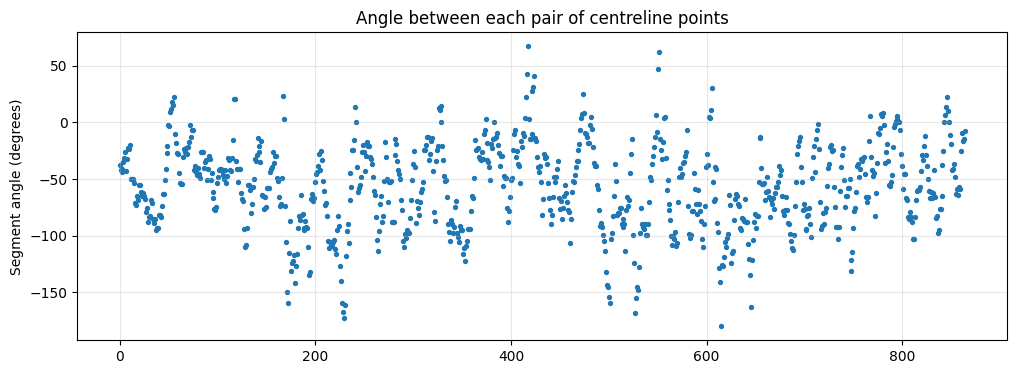

In [43]:

river_cl = gpd.read_file(centreline_file, driver="KML") #this is the centreline from the kml
print(river_cl)          #so we know how the data is so we can plot it
print(river_cl.crs)      #checking the coord!

river_cl_proj = river_cl.to_crs(proj_crs)  #converting from lon/lat to metres

geom = river_cl_proj.geometry.iloc[0]  #from first row, these are the coords for the centreline


all_coords = []  #x is east and y is north

if geom.geom_type == "MultiLineString":
    for part in geom.geoms:
        all_coords.extend(list(part.coords))
else:
    all_coords.extend(list(geom.coords))

coords = np.array(all_coords) #this just takes the coords and puts them in an array!

x = coords[:, 0]
y = coords[:, 1]  #eastings / northings, already projected to metres

print("Number of centreline points:", len(coords))

dx = np.diff(x) #diff between consec
dy = np.diff(y)

river_angle = np.degrees(np.arctan2(dy, dx))  # angle of each segment

mid_x = (x[:-1] + x[1:]) / 2 #mp of segments!
mid_y = (y[:-1] + y[1:]) / 2

segment_id = np.arange(len(river_angle)) #putting in order tbh
#future work maybe, wouldnt dist from centreline potentially be better than segment id ?
plt.figure(figsize=(12, 4))
plt.scatter(segment_id, river_angle, s=8) #quick plot of the segments and the angles between the points.
plt.ylabel("Segment angle (degrees)")
plt.title("Angle between each pair of centreline points")
plt.grid(alpha=0.3)
plt.show()



In [44]:
sat = pd.read_csv(ground_track_file)

#inspected this and found these titles for lon and lat
sat_gdf = gpd.GeoDataFrame(
    sat,
    geometry=gpd.points_from_xy(sat["lon_sat"], sat["lat_sat"]),
    crs="EPSG:4326"
)
sat_proj = sat_gdf.to_crs(proj_crs)

sx = sat_proj.geometry.x.values
sy = sat_proj.geometry.y.values

sat_dx = sx[-1] - sx[0] #diff between first and last points
sat_dy = sy[-1] - sy[0]

sat_angle = np.degrees(np.arctan2(sat_dy, sat_dx)) #then j finding the angleee
print("Satellite ground-track angle:", sat_angle)

Satellite ground-track angle: 73.76432665147382


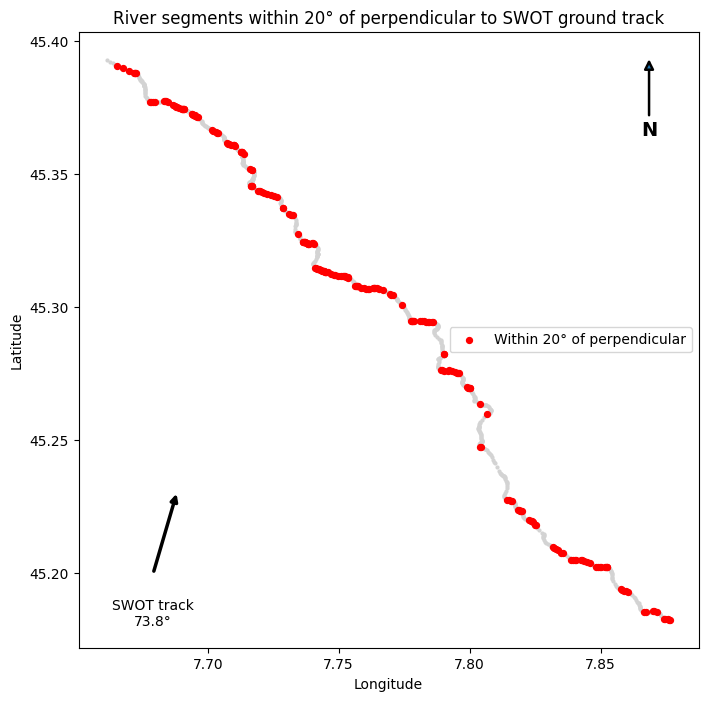

Filtered (long-run) perpendicular segment indices: [  4   5   6   8   9  10  11  48  49  50  51  57  58  59  60  65  66  67
  68  69  70  71  72  73  74  75  83  84  85 138 139 140 141 142 143 144
 145 157 158 159 160 238 239 240 248 249 250 252 253 254 255 256 257 281
 282 283 284 311 312 313 314 315 316 317 318 319 323 324 325 329 330 331
 363 364 365 366 367 368 369 370 371 372 373 374 375 376 377 380 381 382
 383 384 385 386 387 388 402 403 404 405 406 410 411 412 413 414 418 419
 420 421 425 426 427 434 435 436 467 468 469 470 471 476 477 478 479 480
 481 545 546 547 552 553 554 555 556 576 577 578 579 580 692 693 694 695
 712 713 714 715 726 727 728 729 758 759 760 761 774 775 776 777 781 782
 783 784 785 790 791 792 793 796 797 798 799 820 821 822 823 824 848 849
 850 860 861 862 863 864]


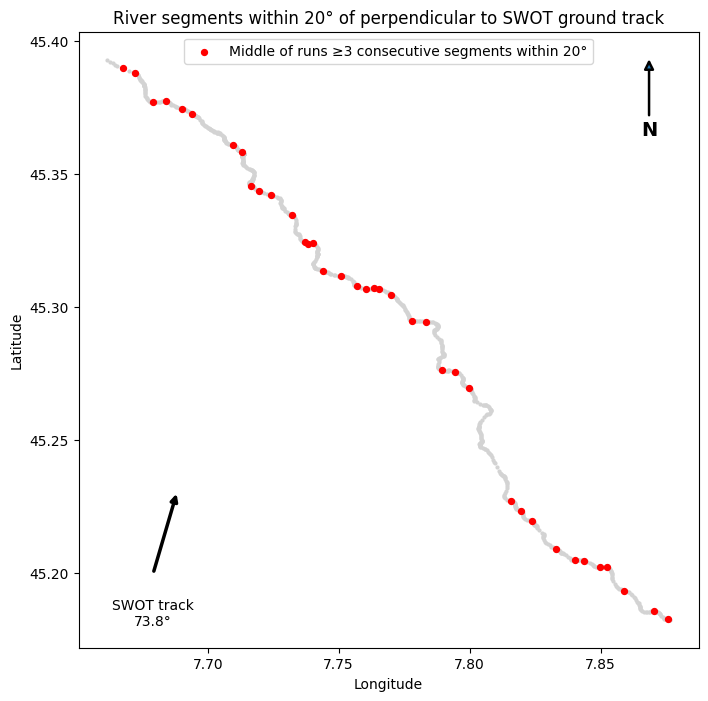

In [59]:
angle_diff = np.abs(river_angle - sat_angle) #diff between
angle_diff = angle_diff % 180  # principle angles
angle_diff = np.where(angle_diff > 90, 180 - angle_diff, angle_diff)  # 90 is perp

#kept in metres (proj_crs) - this is the version everything downstream (distances,
#rotation, plotting on the UTM-based PIXC/AOI maps) should use
midpoints = gpd.GeoDataFrame(
    {"angle_diff": angle_diff, "river_angle": river_angle},
    geometry=gpd.points_from_xy(mid_x, mid_y),
    crs=proj_crs
)
midpoints["segment_index"] = np.arange(len(midpoints))

#a lon/lat COPY, only for the two candidate-overlay plots below which use
#Longitude/Latitude axes - never used for distances or rotation
midpoints_geo = midpoints.to_crs("EPSG:4326") #same but in lon and lat

raw_perp_index = np.where(np.abs(angle_diff - 90) <= angle_tol)[0]
perp_index = raw_perp_index  #candidate segments within tol of perpendicular

perp_runs = np.split( #diff of 1 means are they consec ?
    raw_perp_index,
    np.where(np.diff(raw_perp_index) != 1)[0] + 1
)

perp_midpoints = midpoints.iloc[perp_index].copy()          #metres - used downstream
perp_midpoints_geo = midpoints_geo.iloc[perp_index].copy()  #lon/lat - plotting only


def add_north_and_sat_arrows(ax, sat_angle):
    ax.annotate(
        "N",
        xy=(0.92, 0.96), xytext=(0.92, 0.84),
        xycoords="axes fraction", ha="center", va="center",
        fontsize=14, fontweight="bold",
        arrowprops=dict(arrowstyle="-|>", linewidth=1.8)
    )

    theta_sat = np.radians(sat_angle)
    arrow_start_x, arrow_start_y = 0.12, 0.12
    arrow_length = 0.14
    arrow_dx = arrow_length * np.cos(theta_sat)
    arrow_dy = arrow_length * np.sin(theta_sat)

    ax.annotate(
        "",
        xy=(arrow_start_x + arrow_dx, arrow_start_y + arrow_dy),
        xytext=(arrow_start_x, arrow_start_y),
        xycoords="axes fraction",
        arrowprops=dict(arrowstyle="-|>", linewidth=2.5)
    )
    ax.text(
        arrow_start_x, arrow_start_y - 0.04,
        f"SWOT track\n{sat_angle:.1f}°",
        transform=ax.transAxes, ha="center", va="top", fontsize=10
    )


plt.figure(figsize=(8, 8))
plt.scatter(midpoints_geo.geometry.x, midpoints_geo.geometry.y, s=4, color="lightgrey")
plt.scatter(
    perp_midpoints_geo.geometry.x, perp_midpoints_geo.geometry.y,
    s=18, color="red", label=f"Within {angle_tol}° of perpendicular"
)
ax = plt.gca()
add_north_and_sat_arrows(ax, sat_angle)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"River segments within {angle_tol}° of perpendicular to SWOT ground track")
plt.legend()
plt.show()

runs_over_min = [run for run in perp_runs if len(run) >= min_run]

filtered_index = (
    np.concatenate(runs_over_min)
    if runs_over_min
    else np.array([], dtype=int)
)

perp_midpoints = midpoints.iloc[filtered_index].copy()
perp_midpoints_geo = midpoints_geo.iloc[filtered_index].copy()

middle_indices = [run[len(run) // 2] for run in runs_over_min]

run_midpoints = midpoints.iloc[middle_indices].copy()
run_midpoints_geo = midpoints_geo.iloc[middle_indices].copy()

mid_lon = [midpoints_geo.iloc[i].geometry.x for i in middle]
mid_lat = [midpoints_geo.iloc[i].geometry.y for i in middle]

filtered_index = np.concatenate(runs_over_x) if runs_over_x else np.array([], dtype=int)
print("Filtered (long-run) perpendicular segment indices:", filtered_index)

plt.figure(figsize=(8, 8))
plt.scatter(midpoints_geo.geometry.x, midpoints_geo.geometry.y, s=4, color="lightgrey")
plt.scatter(
    mid_lon, mid_lat,
    s=18, color="red",
    label=f"Middle of runs \u2265{min_run} consecutive segments within {angle_tol}°"
)
ax = plt.gca()
add_north_and_sat_arrows(ax, sat_angle)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"River segments within {angle_tol}° of perpendicular to SWOT ground track")
plt.legend()
plt.show()


In [46]:
pixc = gpd.read_file(pixc_file)  # each row is one pixel
print("PIXC rows:", len(pixc))
print("PIXC CRS:", pixc.crs)
print("PIXC columns:", pixc.columns.tolist())

pixc_proj = pixc.to_crs(proj_crs)

aoi = gpd.read_file(aoi_file)
print("AOI CRS:", aoi.crs)
print("River CRS:", river_cl.crs)

aoi_proj = aoi.to_crs(proj_crs)
pixc_aoi = gpd.clip(pixc_proj, aoi_proj).copy()  # borrowed the clip approach from Lucas's code

print("Number of PIXC points, whole river:", len(pixc_proj))
print("Number of PIXC points inside AOI:", len(pixc_aoi))


PIXC rows: 2630
PIXC CRS: EPSG:4326
PIXC columns: ['height', 'classification', 'classification_qual', 'bright_land_flag', 'geolocation_qual', 'interferogram_qual', 'sig0', 'sig0_qual', 'coherent_power', 'latitude', 'longitude', 'pole_tide', 'height_cor_xover', 'solid_earth_tide', 'pixel_area', 'load_tide_fes', 'load_tide_got', 'iono_cor_gim_ka', 'geoid', 'geometry']
AOI CRS: EPSG:4326
River CRS: EPSG:4326
Number of PIXC points, whole river: 2630
Number of PIXC points inside AOI: 2630


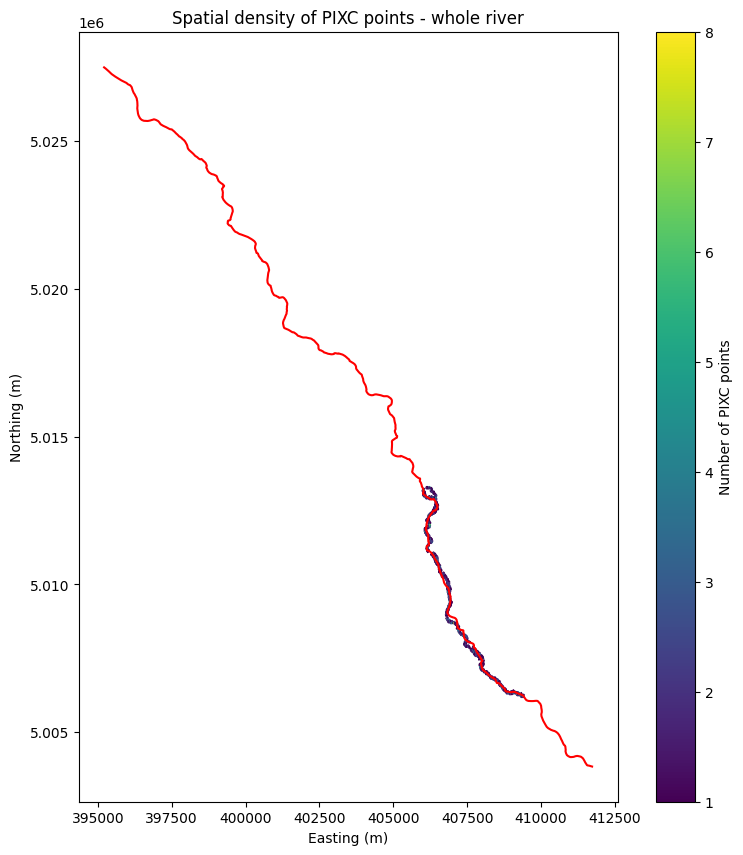

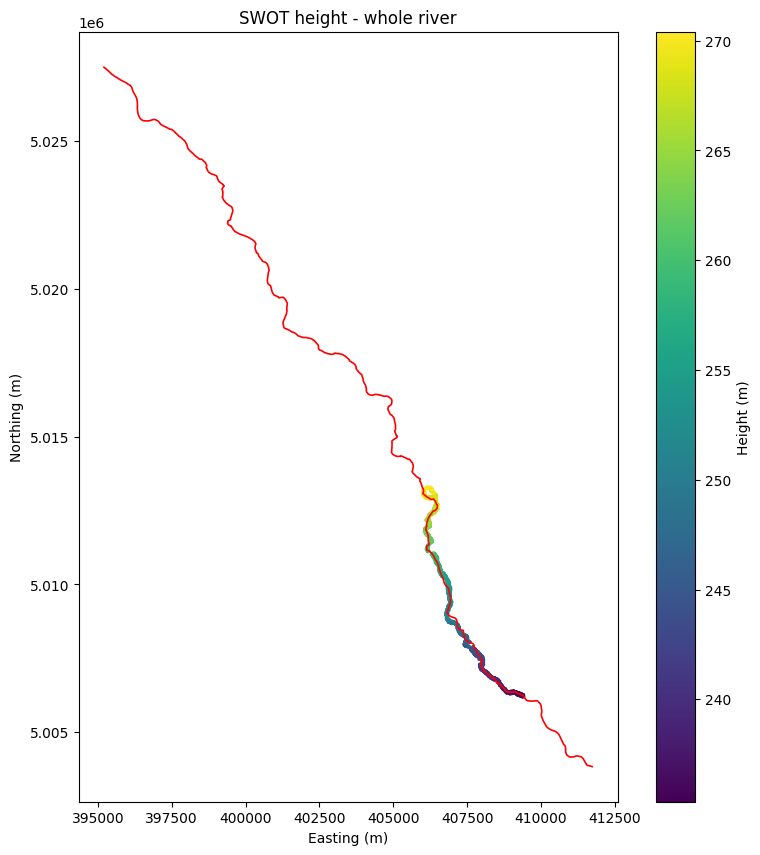

In [47]:
fig, ax = plt.subplots(figsize=(10, 10))
hb = ax.hexbin(pixc_proj.geometry.x, pixc_proj.geometry.y, gridsize=200, mincnt=1)
river_cl_proj.plot(ax=ax, linewidth=1.5, color="red")
plt.colorbar(hb, ax=ax, label="Number of PIXC points")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_title("Spatial density of PIXC points - whole river")
ax.set_aspect("equal")
plt.show()

height_values_river = pixc_proj["height"].replace([np.inf, -np.inf], np.nan)
vmin_r, vmax_r = np.nanpercentile(height_values_river, [2, 98])

fig, ax = plt.subplots(figsize=(10, 10))
pixc_proj.plot(
    ax=ax, column="height", markersize=2, legend=True,
    vmin=vmin_r, vmax=vmax_r, legend_kwds={"label": "Height (m)"}
)
river_cl_proj.plot(ax=ax, linewidth=1.2, color="red")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_title("SWOT height - whole river")
ax.set_aspect("equal")
plt.show()

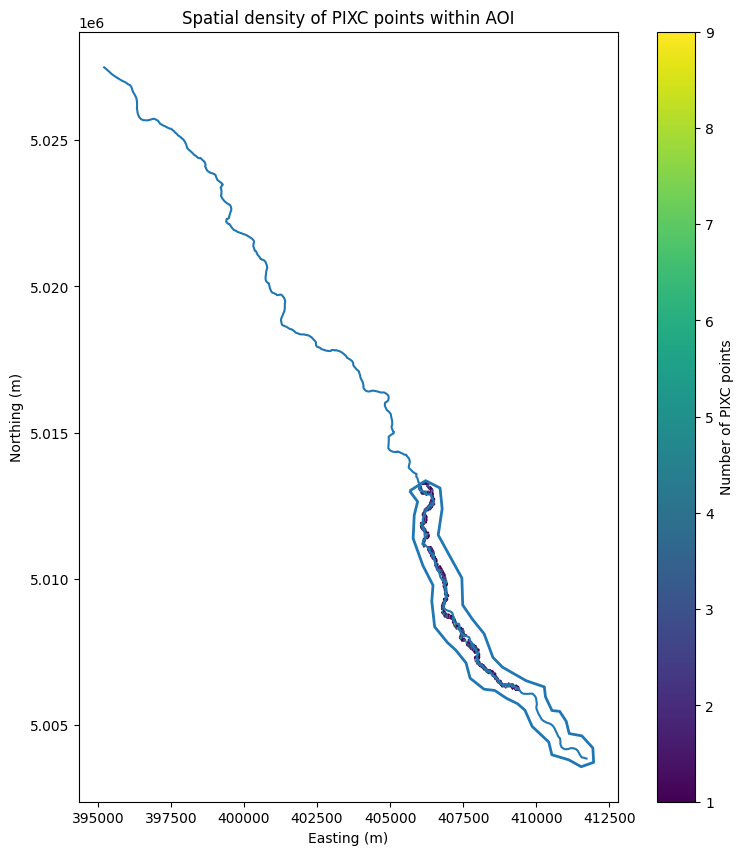

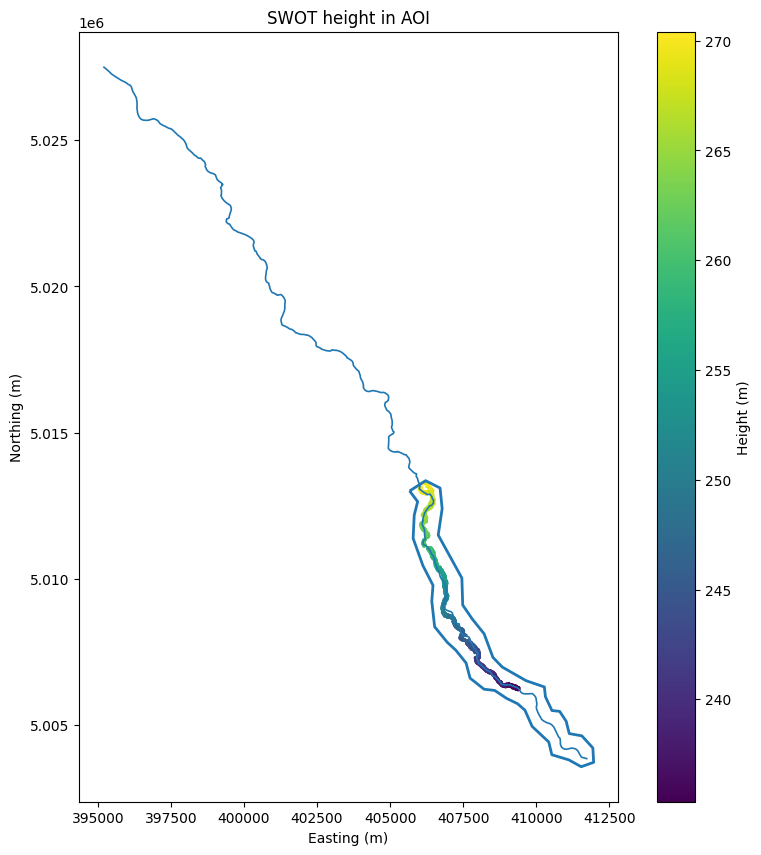

In [48]:
fig, ax = plt.subplots(figsize=(10, 10))
hb = ax.hexbin(pixc_aoi.geometry.x, pixc_aoi.geometry.y, gridsize=150, mincnt=1)
aoi_proj.boundary.plot(ax=ax, linewidth=2)  # like plotting the AOI boundary too
river_cl_proj.plot(ax=ax, linewidth=1.5)
plt.colorbar(hb, ax=ax, label="Number of PIXC points")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_title("Spatial density of PIXC points within AOI")
ax.set_aspect("equal")
plt.show()

height_values_aoi = pixc_aoi["height"].replace([np.inf, -np.inf], np.nan)
vmin_a, vmax_a = np.nanpercentile(height_values_aoi, [2, 98])

fig, ax = plt.subplots(figsize=(10, 10))
pixc_aoi.plot(
    ax=ax, column="height", markersize=2, legend=True,
    vmin=vmin_a, vmax=vmax_a, legend_kwds={"label": "Height (m)"}
)
aoi_proj.boundary.plot(ax=ax, linewidth=2)
river_cl_proj.plot(ax=ax, linewidth=1.2)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_title("SWOT height in AOI")
ax.set_aspect("equal")
plt.show()


PIXC centre: POINT (407202.9934505691 5009456.134842159)
Chosen segment: 695
Chosen midpoint x: 407063.47353476565
Chosen midpoint y: 5008874.045180883
Local river angle: -12.875001561456434
Distance from midpoint to PIXC centre: 598.576795967045 m


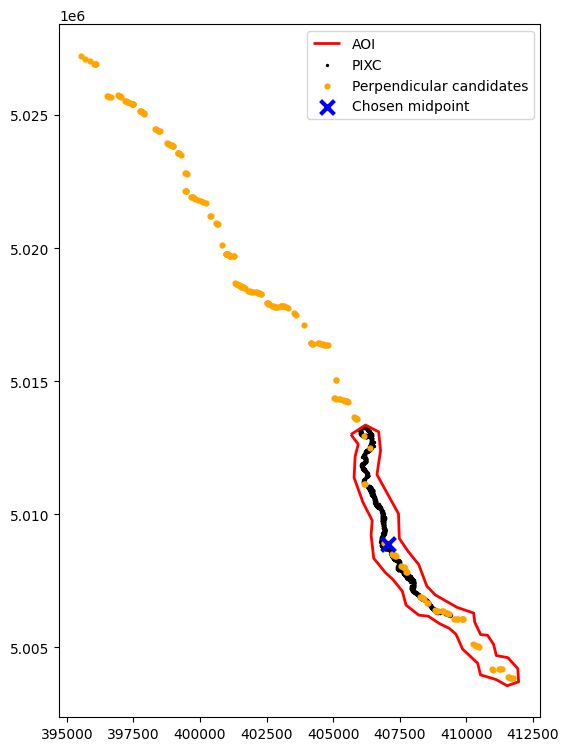

In [49]:
pixc_centre = pixc_aoi.geometry.union_all().centroid
print("PIXC centre:", pixc_centre)

perp_midpoints["distance_to_pixc"] = perp_midpoints.geometry.distance(pixc_centre)

chosen_midpoint = perp_midpoints.loc[perp_midpoints["distance_to_pixc"].idxmin()].copy()
chosen_x = chosen_midpoint.geometry.x
chosen_y = chosen_midpoint.geometry.y
chosen_segment_index = int(chosen_midpoint["segment_index"])
local_river_angle = float(chosen_midpoint["river_angle"])

print("Chosen segment:", chosen_segment_index)
print("Chosen midpoint x:", chosen_x)
print("Chosen midpoint y:", chosen_y)
print("Local river angle:", local_river_angle)
print("Distance from midpoint to PIXC centre:", chosen_midpoint["distance_to_pixc"], "m")

fig, ax = plt.subplots(figsize=(9, 9))
aoi_proj.boundary.plot(ax=ax, color="red", linewidth=2, label="AOI")
pixc_aoi.plot(ax=ax, color="black", markersize=2, label="PIXC")
perp_midpoints.plot(ax=ax, color="orange", markersize=12, label="Perpendicular candidates")
ax.scatter(chosen_x, chosen_y, s=100, color="blue", marker="x", linewidth=3, label="Chosen midpoint")
ax.set_aspect("equal")
ax.legend()
plt.show()


In [50]:
def rotate_to_along_across(gdf, origin_x, origin_y, angle_deg):
    """Rotates point geometries into a river-aligned frame centred on (origin_x, origin_y).
    Returns (along_m, across_m) as numpy arrays."""
    dx_pts = gdf.geometry.x - origin_x
    dy_pts = gdf.geometry.y - origin_y
    theta = np.radians(angle_deg)
    along = dx_pts * np.cos(theta) + dy_pts * np.sin(theta)
    across = -dx_pts * np.sin(theta) + dy_pts * np.cos(theta)
    return along.values, across.values

distance_to_midpoint = pixc_proj.geometry.distance(chosen_midpoint.geometry)
pixc_local = pixc_proj[distance_to_midpoint <= search_radius].copy()
pixc_local["along_m"], pixc_local["across_m"] = rotate_to_along_across(
    pixc_local, chosen_x, chosen_y, local_river_angle
)
print("Points available for rotation (whole-river-local):", len(pixc_local))


pixc_rot = pixc_aoi.copy()
pixc_rot["along_m"], pixc_rot["across_m"] = rotate_to_along_across(
    pixc_rot, chosen_x, chosen_y, local_river_angle
)
print("Points available for rotation (AOI):", len(pixc_rot))

print(pixc_local[["along_m", "across_m"]].describe())
print(pixc_rot[["along_m", "across_m"]].describe())

Points available for rotation (whole-river-local): 275
Points available for rotation (AOI): 2630
          along_m    across_m
count  275.000000  275.000000
mean   -81.613709  -52.350948
std    194.380747  228.910198
min   -308.895980 -417.373446
25%   -261.291842 -202.235937
50%   -138.406446 -138.805362
75%    108.123305  137.339650
max    271.115427  436.475711
           along_m     across_m
count  2630.000000  2630.000000
mean      6.308164   598.543555
std    1381.146808  1962.454277
min   -2007.762585 -2090.494700
25%   -1368.281015 -1103.227080
50%    -277.876062   392.748750
75%    1171.412231  2178.687181
max    2883.270372  4114.538616


Points in cross-river slice, whole-river-local: 10
Points in cross-river slice, AOI: 10


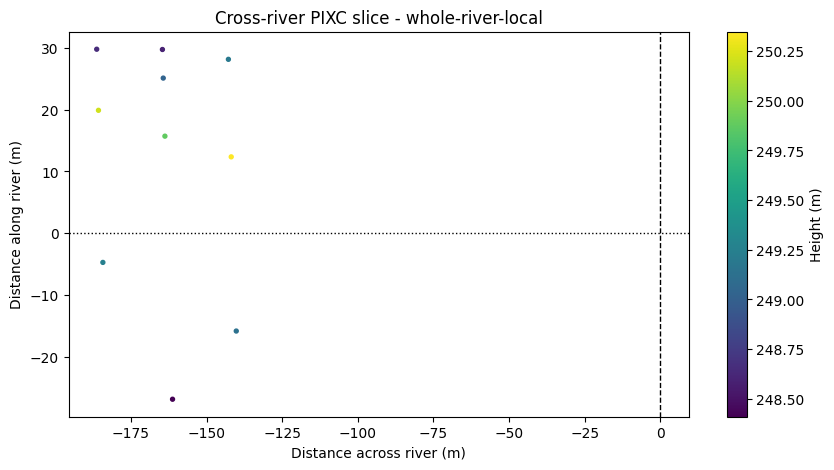

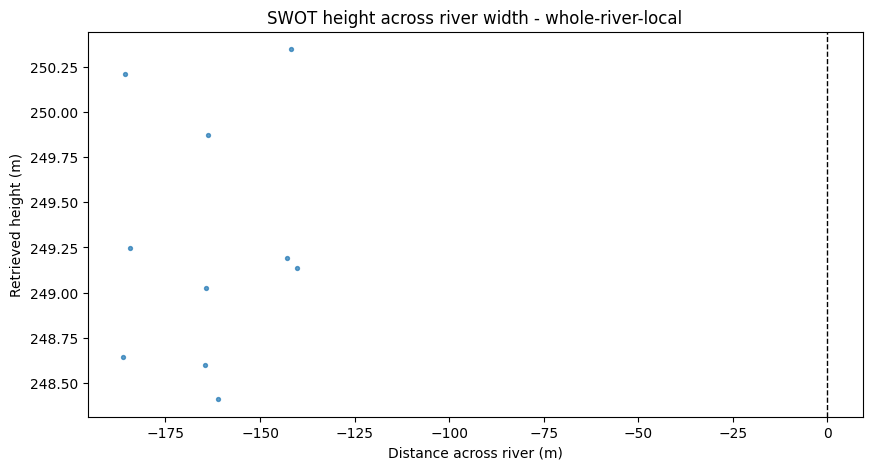

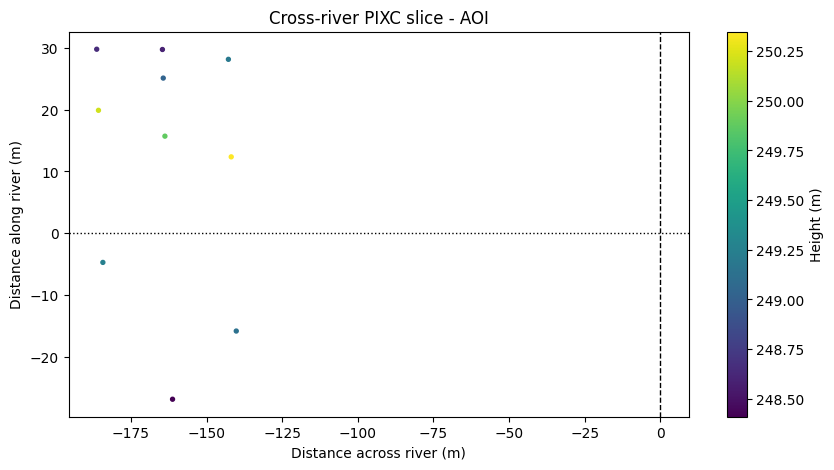

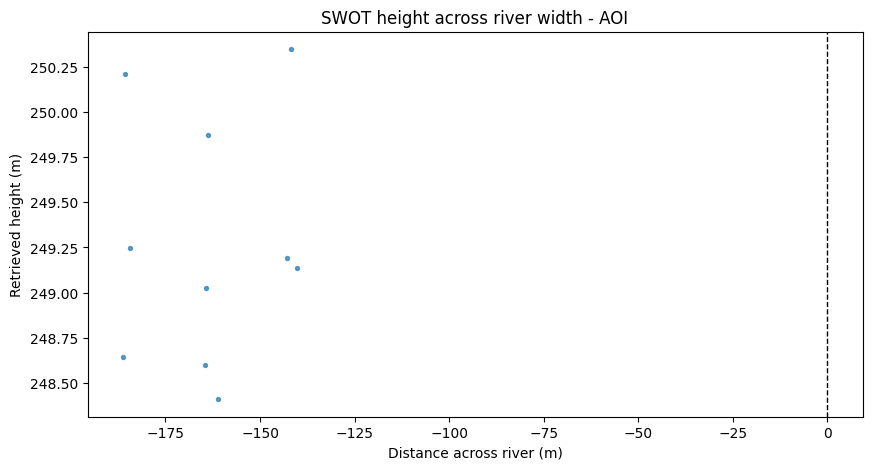

In [51]:
pixc_local_slice = pixc_local[
    (pixc_local["along_m"].abs() <= slice_half_length)
    & (pixc_local["across_m"].abs() <= slice_half_width)
].copy()

pixc_aoi_slice = pixc_rot[
    (pixc_rot["along_m"].abs() <= slice_half_length)
    & (pixc_rot["across_m"].abs() <= slice_half_width)
].copy()

print("Points in cross-river slice, whole-river-local:", len(pixc_local_slice))
print("Points in cross-river slice, AOI:", len(pixc_aoi_slice))


def plot_cross_section(slice_gdf, label):
    plt.figure(figsize=(10, 5))
    sc = plt.scatter(
        slice_gdf["across_m"], slice_gdf["along_m"],
        c=slice_gdf["height"], s=8, cmap="viridis"
    )
    plt.axvline(0, color="black", linestyle="--", linewidth=1)
    plt.axhline(0, color="black", linestyle=":", linewidth=1)
    plt.xlabel("Distance across river (m)")
    plt.ylabel("Distance along river (m)")
    plt.title(f"Cross-river PIXC slice - {label}")
    plt.colorbar(sc, label="Height (m)")
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.scatter(slice_gdf["across_m"], slice_gdf["height"], s=8, alpha=0.7)
    plt.axvline(0, color="black", linestyle="--", linewidth=1)
    plt.xlabel("Distance across river (m)")
    plt.ylabel("Retrieved height (m)")
    plt.title(f"SWOT height across river width - {label}")
    plt.show()


plot_cross_section(pixc_local_slice, "whole-river-local")
plot_cross_section(pixc_aoi_slice, "AOI")

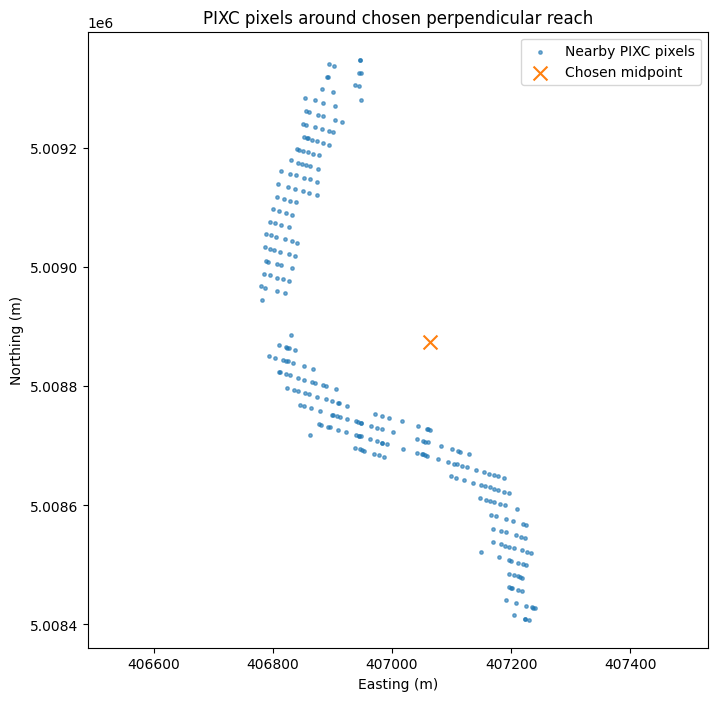

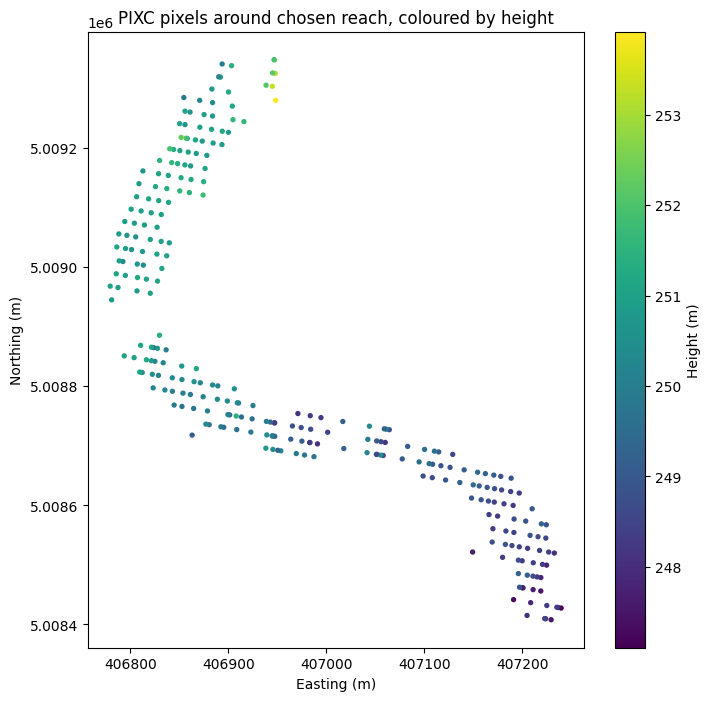

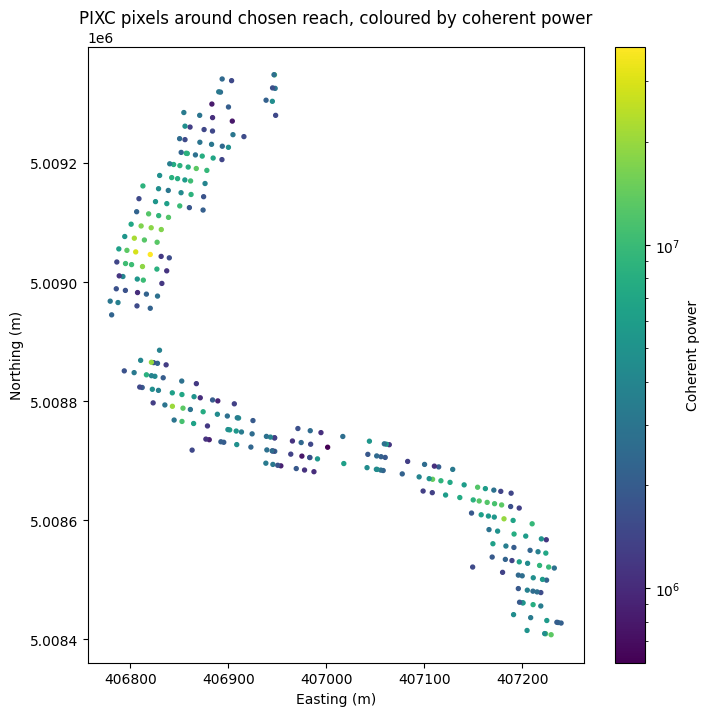

classification_qual
4    275
Name: count, dtype: int64
interferogram_qual
0    275
Name: count, dtype: int64


"this shows there's only one classification value for all the pixels, so no variation (interesting?)"

In [52]:
plt.figure(figsize=(8, 8))
plt.scatter(pixc_local.geometry.x, pixc_local.geometry.y, s=6, alpha=0.6, label="Nearby PIXC pixels")
plt.scatter(chosen_x, chosen_y, marker="x", s=100, label="Chosen midpoint")
plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.title("PIXC pixels around chosen perpendicular reach")
plt.axis("equal")
plt.legend()
plt.show()

plt.figure(figsize=(8, 8))
plt.scatter(pixc_local.geometry.x, pixc_local.geometry.y, c=pixc_local["height"], s=8, cmap="viridis")
plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.title("PIXC pixels around chosen reach, coloured by height")
plt.colorbar(label="Height (m)")
plt.show()

plt.figure(figsize=(8, 8))
plt.scatter(
    pixc_local.geometry.x, pixc_local.geometry.y,
    c=pixc_local["coherent_power"], s=8, cmap="viridis", norm=LogNorm()
)
plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.title("PIXC pixels around chosen reach, coloured by coherent power")
plt.colorbar(label="Coherent power")
plt.show()

#missing points interesting
print(pixc_local["classification_qual"].value_counts())
print(pixc_local["interferogram_qual"].value_counts())
#this shows there's only one classification value for all the pixels, so no variation (interesting?)


save everything (land etc no class or qual) that gives the expected grid. OR via lucas'

In [ ]:
print(pixc_local.columns.tolist())

In [ ]:
def plot_phase_cross_section(
    slice_gdf,
    label,
    phase_col="phase"
):
    valid = slice_gdf.dropna(
        subset=["across_m", "along_m", phase_col]
    ).copy()

    print(f"{label}: {len(valid)} valid phase points")

    plt.figure(figsize=(10, 5))
    sc = plt.scatter(
        valid["across_m"],
        valid["along_m"],
        c=valid[phase_col],
        s=10,
        cmap="twilight",
        vmin=-np.pi,
        vmax=np.pi
    )

    plt.axvline(0, linestyle="--", linewidth=1)
    plt.axhline(0, linestyle=":", linewidth=1)

    plt.xlabel("Distance across river (m)")
    plt.ylabel("Distance along river (m)")
    plt.title(
        f"Wrapped interferometric phase in cross-river slice – {label}"
    )

    cbar = plt.colorbar(sc)
    cbar.set_label("Wrapped phase (rad)")
    cbar.set_ticks(
        [-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi]
    )
    cbar.set_ticklabels(
        ["−π", "−π/2", "0", "π/2", "π"]
    )

    plt.show()

    plt.figure(figsize=(10, 5))
    plt.scatter(
        valid["across_m"],
        valid[phase_col],
        s=10,
        alpha=0.7
    )

    plt.axhline(np.pi, linestyle=":", linewidth=1)
    plt.axhline(-np.pi, linestyle=":", linewidth=1)
    plt.axvline(0, linestyle="--", linewidth=1)

    plt.xlabel("Distance across river (m)")
    plt.ylabel("Wrapped phase (rad)")
    plt.title(
        f"Wrapped phase across river width – {label}"
    )
    plt.ylim(-np.pi - 0.2, np.pi + 0.2)
    plt.show()

ok plots done!